## Testing the Flip Processor Plugin

This notebook demonstrates how to test the custom flip processor plugin you just installed. The flip processor is a teaching example that shows how to extend vLLM's I/O pipeline by subclassing `SegmentationIOProcessor`.

### Prerequisites

Before running this notebook, ensure that:
1. You have installed the flip processor plugin (`uv pip install -e .` from this directory)
2. The vLLM server is running with the plugin enabled:
   ```bash
   vllm serve 1_run_model_in_vllm \
       --skip-tokenizer-init \
       --enable-mm-embeds \
       --io-processor-plugin flip_augmentation \
       --max-num-seqs 32 \
       --enforce-eager

3. The server is accessible at `http://localhost:8000`

### What This Notebook Does

This notebook will:
1. Load and display a sample geospatial image (GeoTIFF format)
2. Send an inference request with flip_horizontal: True to the vLLM server
3. Receive the segmentation mask and visualize it alongside the flipped input
4. Demonstrate that the plugin successfully flipped the image before inference

In [2]:
from pathlib import Path
from tempfile import NamedTemporaryFile
from typing import Any
from urllib.parse import urlparse
import numpy as np
import rasterio
import requests
from rasterio.errors import RasterioIOError
import matplotlib.pyplot as plt
import base64
import json
import requests


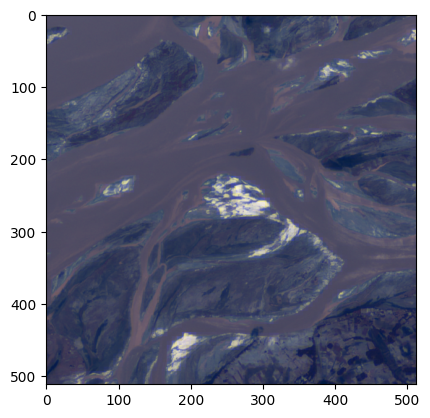

In [3]:
# Read the original image
with rasterio.open("../samples/India_900498_S2Hand.tif") as img_src:
    # Read RGB bands (assuming bands 1, 2, 3 are RGB or similar)
    img_data = img_src.read([3, 2, 1])
    # Transpose to (height, width, channels) for matplotlib
    img_rgb = np.transpose(img_data, (1, 2, 0))
    # Normalize to 0-1 range for display
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())

plt.imshow(img_rgb)

In [ ]:
payload = {
    "data": {
        "data": "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/resolve/main/examples/India_900498_S2Hand.tif",
        "indices": [1, 2, 3, 8, 11, 12],
        "data_format": "url",
        "out_data_format": "b64_json",
        "image_format": "tiff",
        "flip_horizontal": True,
    },
    "model": "1_run_model_in_vllm",
}

response = requests.post(
    "http://localhost:8000/pooling",
    headers={"Content-Type": "application/json"},
    data=json.dumps(payload),
)

if response.status_code == 200:
    result = response.json()
    mask_b64 = result["data"]["data"]
    mask_bytes = base64.b64decode(mask_b64)
    with open("mask.tiff", "wb") as f:
        f.write(mask_bytes)
    print("Segmentation mask saved as mask.tiff")
else:
    print(f"Error: Received status code {response.status_code}")
    print(f"Response: {response.text}")


Segmentation mask saved as mask.tiff


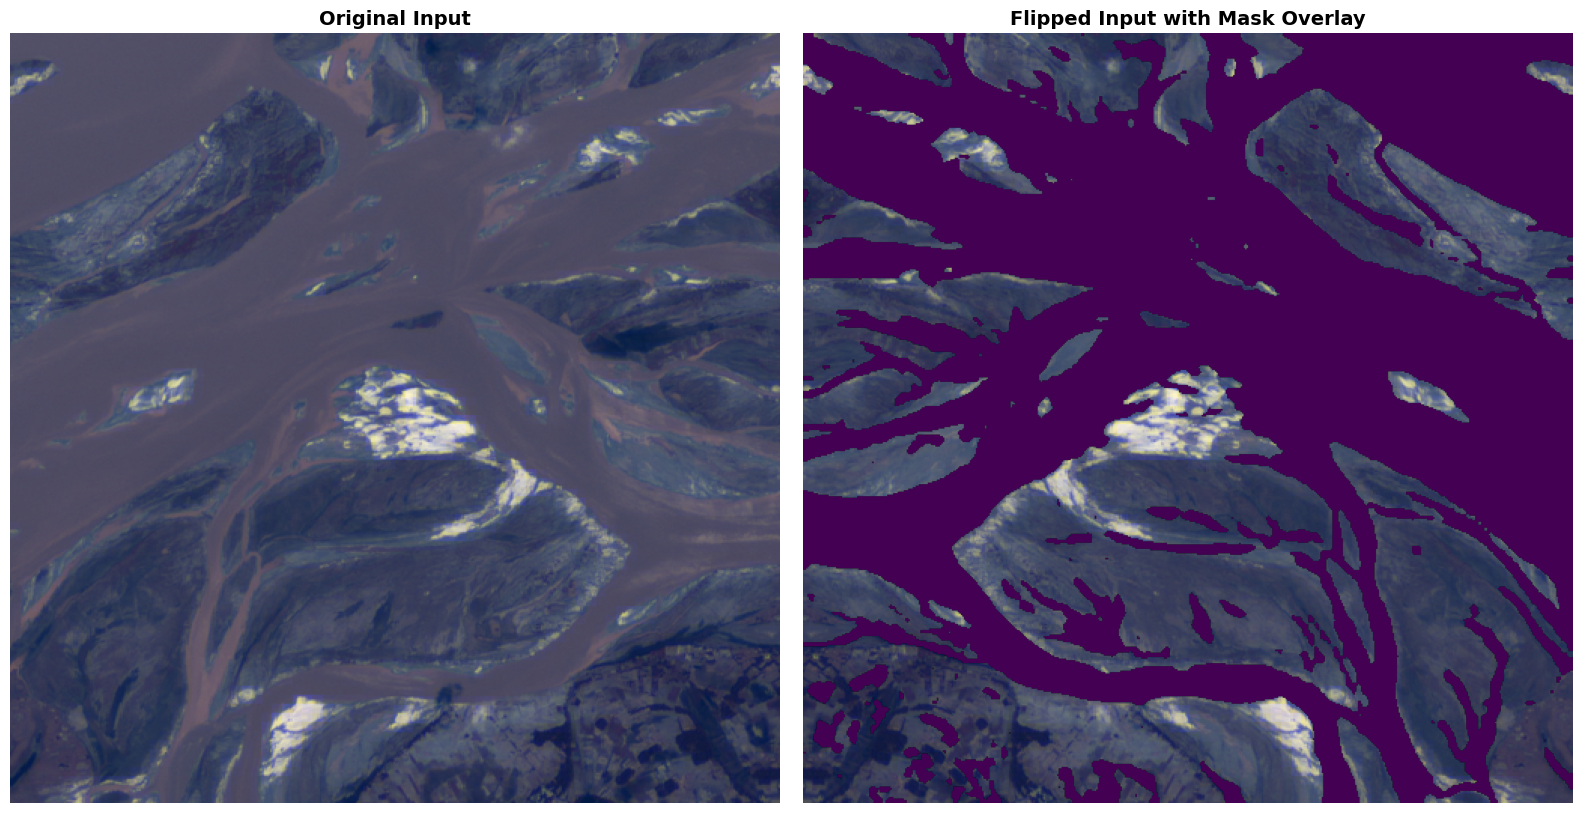

In [7]:
# Read the mask
with rasterio.open('mask.tiff') as mask_src:
    mask = mask_src.read(1)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Show mask only
axes[0].imshow(img_rgb, cmap='viridis')
axes[0].set_title('Original Input', fontsize=14, fontweight='bold')
axes[0].axis('off')

img_flipped = np.flip(img_rgb, axis=1)

# Right: Show original image with mask overlay
axes[1].imshow(img_flipped)
# Overlay mask with transparency
mask_overlay = np.ma.masked_where(mask == 0, mask)
axes[1].imshow(mask_overlay)
axes[1].set_title('Flipped Input with Mask Overlay', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()